<a href="https://colab.research.google.com/github/XiaoyangLYY/portfolio-optimization/blob/main/optimization_lxy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
# ============================================================
# FULL PIPELINE — S&P 500 股票组合选股
# Choice 2: 30支个股，周频数据，月度调仓，rolling window = 1年
# ============================================================

import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import yfinance as yf
import requests
from io import StringIO
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: 获取 S&P 500 成分股 + 行业信息
# ============================================================

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
sp500 = pd.read_html(StringIO(response.text))[0]
sp500 = sp500[['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry']].copy()
sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-', regex=False)

print(f"S&P 500 成分股数量: {len(sp500)}")
print(f"行业分布:\n{sp500['GICS Sector'].value_counts().to_string()}")

# ============================================================
# STEP 2: 下载价格数据
# ============================================================

tickers = sp500['Symbol'].tolist()

raw = yf.download(
    tickers,
    start="2016-01-01",
    end="2026-01-01",
    interval="1wk",
    auto_adjust=True,
    group_by='ticker',
    progress=True
)

# 适配新版 yfinance: columns.names = ['Price', 'Ticker']
print(f"\nyfinance MultiIndex level names: {raw.columns.names}")

close  = raw.xs('Close',  axis=1, level='Price').copy()
volume = raw.xs('Volume', axis=1, level='Price').copy()



[                       0%                       ]  2 of 503 completed

S&P 500 成分股数量: 503
行业分布:
GICS Sector
Industrials               79
Financials                76
Information Technology    71
Health Care               60
Consumer Discretionary    48
Consumer Staples          36
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22


[*********************100%***********************]  503 of 503 completed
[*********************101%***********************]  508 of 503 completed


yfinance MultiIndex level names: ['Ticker', 'Price']



清洗后 close shape:  (522, 503)
清洗后 volume shape: (522, 503)
时间范围: 2016-01-01 → 2025-12-26

过滤稀疏ticker后 prices shape: (522, 468)
（删除了 35 个数据不足的ticker）

returns shape: (521, 468)
可用ticker数: 468

有效股票数: 468
覆盖行业数: 11

各行业分配名额 (合计=30):
GICS Sector
Information Technology    3
Consumer Discretionary    3
Financials                3
Communication Services    3
Health Care               3
Industrials               3
Consumer Staples          3
Energy                    3
Utilities                 2
Materials                 2
Real Estate               2

  最终 Portfolio（30 支股票）
Symbol                Security            GICS Sector  proxy_mktcap
  TSLA             Tesla, Inc. Consumer Discretionary  7.167980e+10
  AAPL              Apple Inc. Information Technology  4.439207e+10
  AMZN                  Amazon Consumer Discretionary  3.656242e+10
  MSFT               Microsoft Information Technology  2.886689e+10
  NVDA                  Nvidia Information Technology  2.398394e+10
  META          M

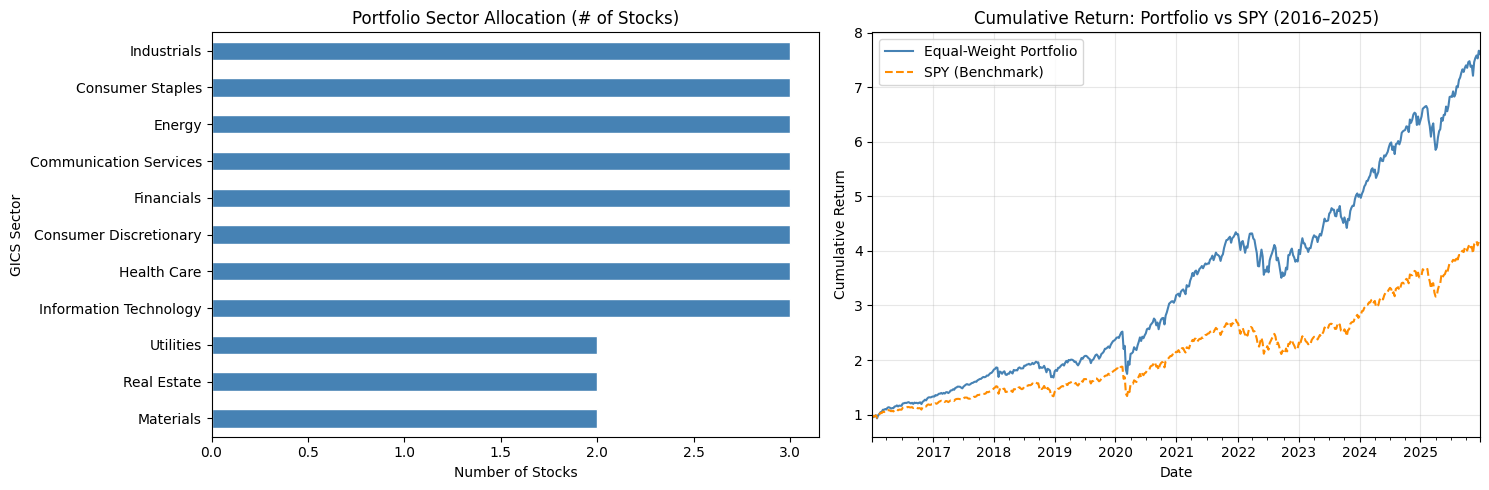

图表已保存

  后续可直接使用的变量：
  portfolio        → 30支股票信息 DataFrame
  ptickers         → 30支股票 ticker 列表
  portfolio_prices → 周收盘价  (weeks × 30)
  portfolio_returns→ 周收益率  (weeks × 30)
  prices           → 全市场周收盘价
  returns          → 全市场周收益率


In [37]:
# ============================================================
# STEP 3: 清洗 — 删除非交易周空行
# ============================================================

# 删除全部或绝大多数股票都是NaN的行（非交易周、节假日）
row_coverage = close.notna().mean(axis=1)        # 每行有数据的股票比例
close  = close[row_coverage > 0.5].copy()        # 超过50%股票有数据才保留
volume = volume[volume.notna().mean(axis=1) > 0.5].copy()

# 对齐 index
common_index = close.index.intersection(volume.index)
close  = close.loc[common_index]
volume = volume.loc[common_index]

print(f"\n清洗后 close shape:  {close.shape}")
print(f"清洗后 volume shape: {volume.shape}")
print(f"时间范围: {close.index[0].date()} → {close.index[-1].date()}")

# ============================================================
# STEP 4: 过滤稀疏 ticker（要求至少85%周有数据）
# ============================================================

thresh = int(len(close) * 0.85)
prices = close.dropna(axis=1, thresh=thresh).copy()

print(f"\n过滤稀疏ticker后 prices shape: {prices.shape}")
print(f"（删除了 {close.shape[1] - prices.shape[1]} 个数据不足的ticker）")

# ============================================================
# STEP 5: 生成周收益率
# ============================================================

returns = prices.pct_change()
returns = returns.iloc[1:]                        # 删除第一行NaN
returns = returns.dropna(axis=1, how='any')       # 删除任意含NaN的列（保证矩阵完整）

print(f"\nreturns shape: {returns.shape}")
print(f"可用ticker数: {returns.shape[1]}")

# ============================================================
# STEP 6: 计算代理市值，每行业选代表性股票
# 均匀分配：11行业，8个行业3支 + 3个行业2支 = 30支
# 代理市值 = median(Close × Volume)，只用 returns 里存在的ticker
# ============================================================

# 只保留 returns 中有完整数据的 ticker
valid_tickers = returns.columns.tolist()
close_v  = close[valid_tickers]
volume_v = volume[valid_tickers]

# 计算代理市值
turnover     = close_v * volume_v
proxy_mktcap = turnover.median(axis=0).rename("proxy_mktcap")

# 合并行业信息
stock_info = (sp500[sp500['Symbol'].isin(valid_tickers)]
              .set_index('Symbol')
              .copy())
stock_info['proxy_mktcap'] = proxy_mktcap
stock_info = stock_info.dropna(subset=['proxy_mktcap'])

print(f"\n有效股票数: {len(stock_info)}")
print(f"覆盖行业数: {stock_info['GICS Sector'].nunique()}")

# 分配名额：按行业总代理市值排序，前8大行业各3支，后3个行业各2支
PORTFOLIO_SIZE = 30
n_sectors      = stock_info['GICS Sector'].nunique()
base           = PORTFOLIO_SIZE // n_sectors          # = 2
extra          = PORTFOLIO_SIZE % n_sectors           # = 8

sector_total = (stock_info.groupby('GICS Sector')['proxy_mktcap']
                .sum()
                .sort_values(ascending=False))
sector_quota = pd.Series(base, index=sector_total.index)
sector_quota.iloc[:extra] += 1

print(f"\n各行业分配名额 (合计={sector_quota.sum()}):")
print(sector_quota.sort_values(ascending=False).to_string())

# 每行业选 proxy_mktcap 最大的 N 支
selected = []
for sector, n in sector_quota.items():
    top_n = (stock_info[stock_info['GICS Sector'] == sector]
             .nlargest(n, 'proxy_mktcap'))
    selected.append(top_n)

portfolio = (pd.concat(selected)
               .sort_values('proxy_mktcap', ascending=False)
               .reset_index())

print(f"\n{'='*55}")
print(f"  最终 Portfolio（{len(portfolio)} 支股票）")
print(f"{'='*55}")
print(portfolio[['Symbol', 'Security', 'GICS Sector', 'proxy_mktcap']]
      .to_string(index=False))

# ============================================================
# STEP 7: 提取 Portfolio 的价格和收益率
# ============================================================

ptickers        = portfolio['Symbol'].tolist()
portfolio_prices  = prices[ptickers].copy()
portfolio_returns = returns[ptickers].copy()

print(f"\nportfolio_prices  shape: {portfolio_prices.shape}")
print(f"portfolio_returns shape: {portfolio_returns.shape}")

# ============================================================
# STEP 8: 可视化
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 左图：各行业名额
sector_quota.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Portfolio Sector Allocation (# of Stocks)', fontsize=12)
axes[0].set_xlabel('Number of Stocks')

# 右图：等权累计收益率 vs SPY
eq_returns = portfolio_returns.mean(axis=1)
cum_eq = (1 + eq_returns).cumprod()

# 下载SPY，明确去掉timezone
spy_raw = yf.download('SPY', start="2016-01-01", end="2026-01-01",
                      interval='1wk', auto_adjust=True, progress=False)
spy_close = spy_raw['Close'].squeeze()
spy_close.index = pd.to_datetime(spy_close.index).tz_localize(None)
spy_ret = spy_close.pct_change().dropna()

# 用 reindex 对齐到 portfolio_returns 的 index
spy_ret_aligned = spy_ret.reindex(portfolio_returns.index)
cum_spy = (1 + spy_ret_aligned).cumprod()

cum_eq.plot(ax=axes[1], label='Equal-Weight Portfolio', color='steelblue')
cum_spy.plot(ax=axes[1], label='SPY (Benchmark)', color='darkorange', linestyle='--')
axes[1].set_title('Cumulative Return: Portfolio vs SPY (2016–2025)', fontsize=12)
axes[1].set_ylabel('Cumulative Return')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
os.makedirs('results', exist_ok=True)  # 先创建文件夹
plt.tight_layout()
plt.savefig('results/portfolio_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存")


# ============================================================
# STEP 9: 保存关键变量（供后续 clustering / 优化使用）
# ============================================================

print(f"\n{'='*40}")
print("  后续可直接使用的变量：")
print(f"{'='*40}")
print("  portfolio        → 30支股票信息 DataFrame")
print("  ptickers         → 30支股票 ticker 列表")
print("  portfolio_prices → 周收盘价  (weeks × 30)")
print("  portfolio_returns→ 周收益率  (weeks × 30)")
print("  prices           → 全市场周收盘价")
print("  returns          → 全市场周收益率")

=== 方法A：全局Clustering选出的30支股票 ===
Symbol                      Security            GICS Sector
  NWSA           News Corp (Class A) Communication Services
  NFLX                       Netflix Communication Services
   AZO                      AutoZone Consumer Discretionary
   RCL         Royal Caribbean Group Consumer Discretionary
   TJX                 TJX Companies Consumer Discretionary
   PHM                    PulteGroup Consumer Discretionary
  COST                        Costco       Consumer Staples
   PEP                       PepsiCo       Consumer Staples
   EOG                 EOG Resources                 Energy
   BLK                     BlackRock             Financials
  MRSH                Marsh McLennan             Financials
   PRU          Prudential Financial             Financials
    RF Regions Financial Corporation             Financials
  SPGI                    S&P Global             Financials
   TRV     Travelers Companies (The)             Financials
   ELV 

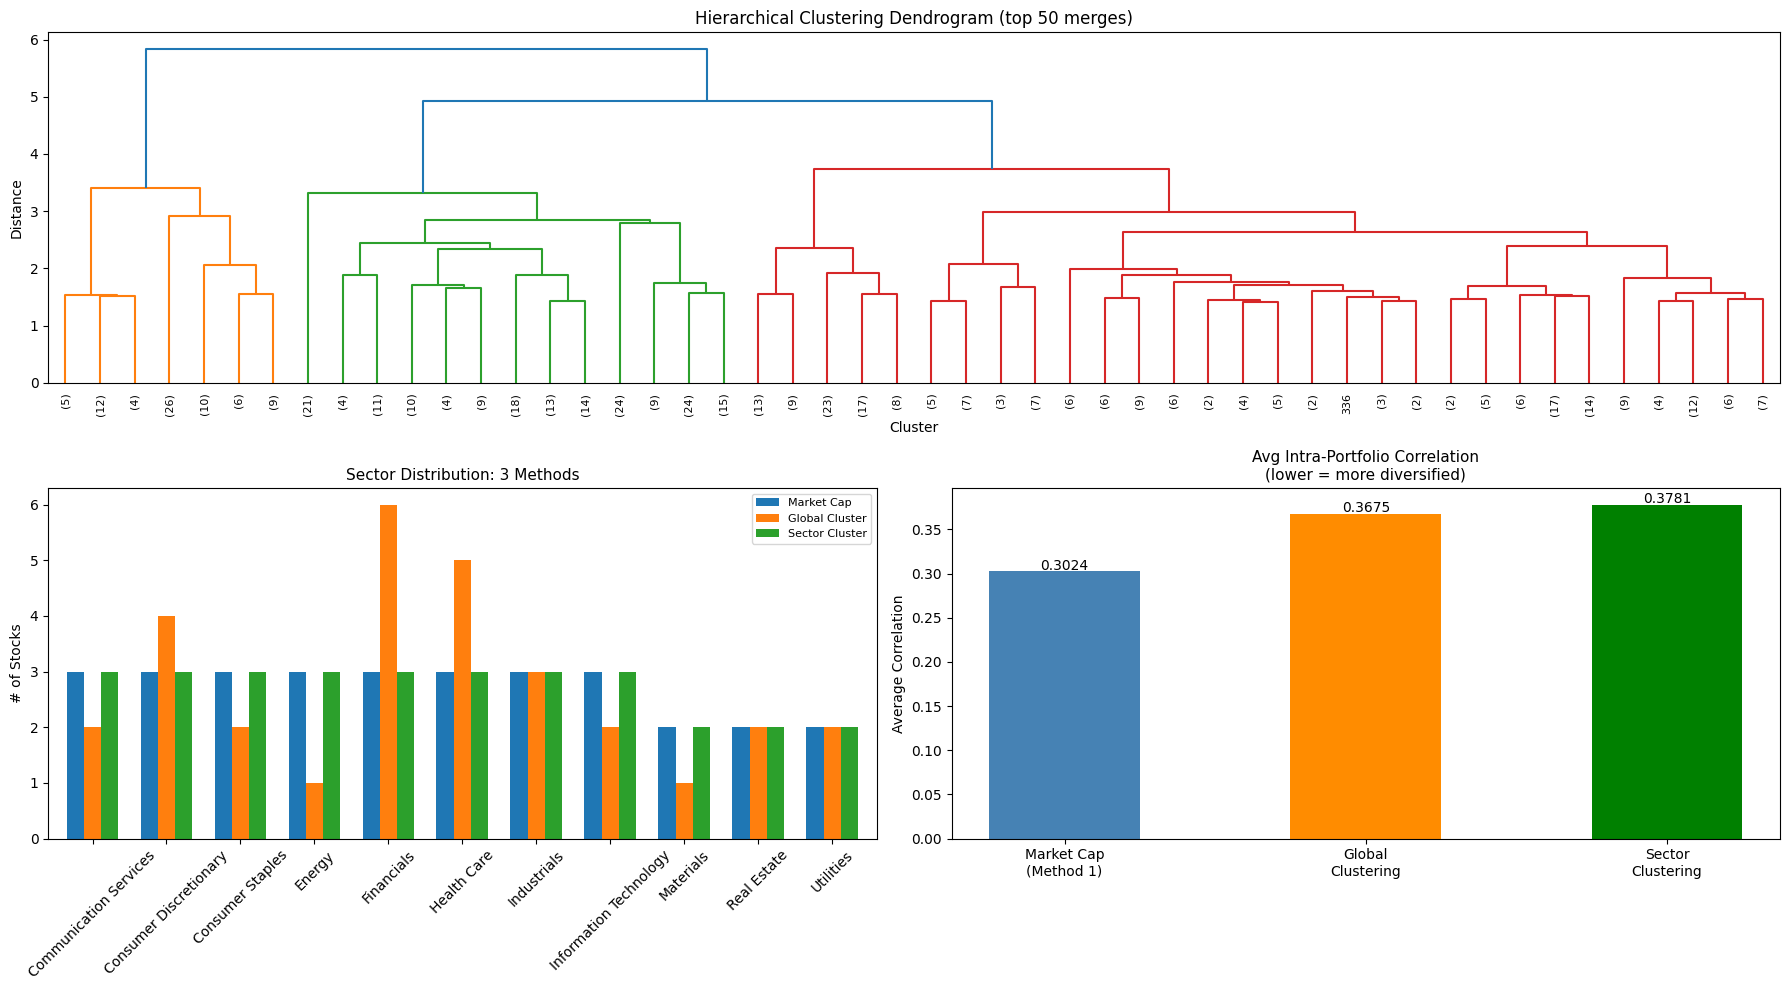

图表已保存

portfolio_returns_cluster shape: (521, 30)
portfolio_prices_cluster  shape: (522, 30)


In [38]:
# ============================================================
# 方法二：Hierarchical Clustering 选股
# 两种方式：
#   A. 全局clustering：直接对468支股票聚成30类
#   B. 行业内clustering：每个行业内部聚类，再汇总30支
# ============================================================

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# ============================================================
# 准备数据：用全市场 returns（468支股票）
# ============================================================

# 相关性矩阵 → 距离矩阵
corr_matrix = returns.corr()                          # (468, 468)
dist_matrix = np.sqrt(2 * (1 - corr_matrix))         # 标准金融距离公式
dist_condensed = squareform(dist_matrix, checks=False)

# 层次聚类（Ward方法，最常用）
Z = linkage(dist_condensed, method='ward')

# ============================================================
# 方法 A：全局 Clustering → 30 个 cluster
# ============================================================

N_CLUSTERS = 30
labels_global = fcluster(Z, N_CLUSTERS, criterion='maxclust')
cluster_df = pd.DataFrame({
    'Symbol': returns.columns,
    'Cluster_Global': labels_global
})

# 每个 cluster 选离中心最近的股票（最具代表性）
selected_global = []
for c in range(1, N_CLUSTERS + 1):
    members = cluster_df[cluster_df['Cluster_Global'] == c]['Symbol'].tolist()
    if len(members) == 1:
        selected_global.append(members[0])
        continue
    # 计算 cluster 内部平均相关性，选相关性最高的（最中心的）
    sub_corr = corr_matrix.loc[members, members]
    avg_corr = sub_corr.mean(axis=1)
    center = avg_corr.idxmax()
    selected_global.append(center)

portfolio_global = (stock_info.loc[selected_global]
                    .reset_index()[['Symbol','Security','GICS Sector','proxy_mktcap']]
                    .sort_values('GICS Sector'))

print("=== 方法A：全局Clustering选出的30支股票 ===")
print(portfolio_global[['Symbol','Security','GICS Sector']].to_string(index=False))
print(f"\n行业分布:\n{portfolio_global['GICS Sector'].value_counts().to_string()}")

# ============================================================
# 方法 B：行业内 Clustering → 每行业聚类，共30支
# 分配名额和方法一相同：8个行业3支 + 3个行业2支
# ============================================================

# 复用方法一的 sector_quota
selected_sector = []
for sector, n in sector_quota.items():
    sector_tickers = stock_info[stock_info['GICS Sector'] == sector].index.tolist()
    sector_tickers = [t for t in sector_tickers if t in returns.columns]

    if len(sector_tickers) <= n:
        selected_sector.extend(sector_tickers)
        continue

    # 行业内相关性距离矩阵
    sub_corr = corr_matrix.loc[sector_tickers, sector_tickers]
    sub_dist = np.sqrt(2 * (1 - sub_corr))
    sub_condensed = squareform(sub_dist, checks=False)

    # 行业内聚类成 n 个 cluster
    Z_sector = linkage(sub_condensed, method='ward')
    sub_labels = fcluster(Z_sector, n, criterion='maxclust')

    for c in range(1, n + 1):
        members = [sector_tickers[i] for i, l in enumerate(sub_labels) if l == c]
        if not members:
            continue
        if len(members) == 1:
            selected_sector.append(members[0])
            continue
        sub_sub_corr = corr_matrix.loc[members, members]
        avg_corr = sub_sub_corr.mean(axis=1)
        selected_sector.append(avg_corr.idxmax())

portfolio_sector = (stock_info.loc[selected_sector]
                    .reset_index()[['Symbol','Security','GICS Sector','proxy_mktcap']]
                    .sort_values('GICS Sector'))

print("\n=== 方法B：行业内Clustering选出的30支股票 ===")
print(portfolio_sector[['Symbol','Security','GICS Sector']].to_string(index=False))
print(f"\n行业分布:\n{portfolio_sector['GICS Sector'].value_counts().to_string()}")

# ============================================================
# 对比三种方法的行业分布 + 组合内平均相关性
# ============================================================

def avg_intra_corr(tickers, corr_matrix):
    """计算组合内股票的平均两两相关性（越低越分散）"""
    sub = corr_matrix.loc[tickers, tickers]
    n = len(tickers)
    return (sub.sum().sum() - n) / (n * (n - 1))

t1 = portfolio['Symbol'].tolist()          # 方法一：市值
t2 = portfolio_global['Symbol'].tolist()   # 方法二A：全局clustering
t3 = portfolio_sector['Symbol'].tolist()   # 方法二B：行业内clustering

print("\n=== 三种方法组合内平均相关性（越低越分散）===")
print(f"方法一  市值选股:        {avg_intra_corr(t1, corr_matrix):.4f}")
print(f"方法二A 全局Clustering:  {avg_intra_corr(t2, corr_matrix):.4f}")
print(f"方法二B 行业内Clustering:{avg_intra_corr(t3, corr_matrix):.4f}")

# ============================================================
# 可视化：Dendrogram + 三种方法行业分布对比
# ============================================================

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# 左上：Dendrogram（只显示最后50个合并，太密看不清）
ax1 = fig.add_subplot(gs[0, :])
dendrogram(Z, truncate_mode='lastp', p=50,
           leaf_rotation=90, leaf_font_size=8, ax=ax1)
ax1.set_title('Hierarchical Clustering Dendrogram (top 50 merges)', fontsize=12)
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Distance')

# 左下：三种方法行业分布对比
ax2 = fig.add_subplot(gs[1, 0])
sector_counts = pd.DataFrame({
    'Market Cap':      portfolio['GICS Sector'].value_counts(),
    'Global Cluster':  portfolio_global['GICS Sector'].value_counts(),
    'Sector Cluster':  portfolio_sector['GICS Sector'].value_counts(),
}).fillna(0).astype(int)
sector_counts.plot(kind='bar', ax=ax2, width=0.7)
ax2.set_title('Sector Distribution: 3 Methods', fontsize=11)
ax2.set_xlabel('')
ax2.set_ylabel('# of Stocks')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=8)

# 右下：组合内平均相关性对比
ax3 = fig.add_subplot(gs[1, 1])
methods = ['Market Cap\n(Method 1)', 'Global\nClustering', 'Sector\nClustering']
corrs = [avg_intra_corr(t1, corr_matrix),
         avg_intra_corr(t2, corr_matrix),
         avg_intra_corr(t3, corr_matrix)]
bars = ax3.bar(methods, corrs, color=['steelblue', 'darkorange', 'green'], width=0.5)
ax3.set_title('Avg Intra-Portfolio Correlation\n(lower = more diversified)', fontsize=11)
ax3.set_ylabel('Average Correlation')
for bar, val in zip(bars, corrs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
import os; os.makedirs('results', exist_ok=True)
plt.savefig('results/clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存")



# 方法二B（行业内clustering）作为主要的第二方法
ptickers_cluster   = portfolio_sector['Symbol'].tolist()
portfolio_returns_cluster = returns[ptickers_cluster].copy()
portfolio_prices_cluster  = prices[ptickers_cluster].copy()

print(f"\nportfolio_returns_cluster shape: {portfolio_returns_cluster.shape}")
print(f"portfolio_prices_cluster  shape: {portfolio_prices_cluster.shape}")